In [1]:
from pathlib import Path
import json
from py_markdown_table.markdown_table import markdown_table
from numpy import load
from torch import from_numpy
from deepinv.utils import plot

In [2]:
# Knee acc 6
ids = {
    "sup": "jqht7upm",
    "ei": "w46f0xqe",
    "diffeo-mo-ei": "dijz21sj"
}

Load results

In [3]:
results = {}
for title, id in ids.items():
    with open(f"M:/models/deepinv-selfsup-fastmri/paper/{id}/results.json", "r") as f:
        results[title] = json.load(f)
    results[title]["sample"] = load(f"models/paper/{id}/samples.npz")

In [13]:
def repr(m, dp=3, p='+'):
    return rf"{str(round(m, dp)).lstrip('0')}" if (m is not None and m != "") else ""
table = [
    {
        "name": k,
        "PSNR": repr(run["PSNR"], 2),
        "PSNR_nl": repr(run["PSNR no learning"], 2),
        "SSIM": repr(run["SSIM"], 4),
        "SSIM_nl": repr(run["SSIM no learning"], 4),
    } for k, run in results.items()
]
print(markdown_table(table).set_params(row_sep="markdown").get_markdown())

```|    name    | PSNR|PSNR_nl| SSIM|SSIM_nl|
|------------|-----|-------|-----|-------|
|     sup    |32.68| 27.98 |.8141| .7041 |
|     ei     |31.08| 27.98 |.7582| .7041 |
|diffeo-mo-ei|31.91| 27.98 |.7848| .7041 |```


In [14]:
print(rf'ZF & {table[0]["PSNR_nl"]} & {table[0]["SSIM_nl"]} \\')
for m in table:
    print(rf'{m["name"]} & {m["PSNR"]} & {m["SSIM"]} \\')

ZF & 27.98 & .7041 \\
sup & 32.68 & .8141 \\
ei & 31.08 & .7582 \\
diffeo-mo-ei & 31.91 & .7848 \\


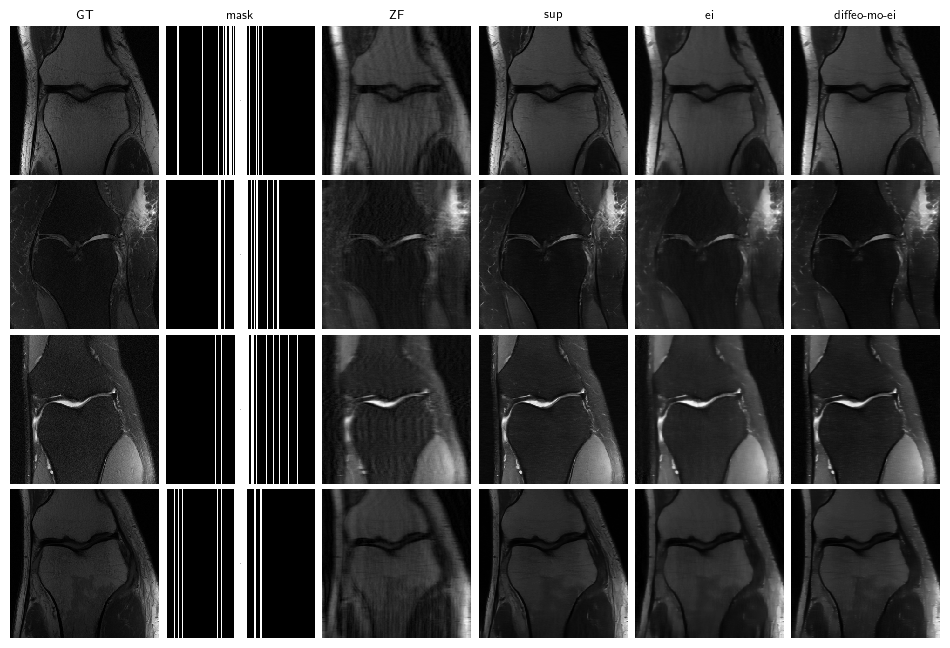

In [7]:
x = from_numpy(results["diffeo-mo-ei"]["sample"]["x"])
x_init = from_numpy(results["diffeo-mo-ei"]["sample"]["x_init"])
y = from_numpy(results["diffeo-mo-ei"]["sample"]["y"])

plot({
    "GT": x, 
    "mask": y != 0, 
    "ZF": x_init
} | {
    k: from_numpy(results[k]["sample"]["x_hat"]) for k in results
}, save_fn="models/paper/knee_6.png", dpi=1200)